In [19]:
import os

base = "C:/transformer_project/dataset"

folders = [
    "train/images",
    "train/labels",
    "val/images",
    "val/labels"
]

for f in folders:
    os.makedirs(os.path.join(base, f), exist_ok=True)

print("dataset structure created")

dataset structure created


<h3>Frame Extraction from Video </h3>

In [ ]:
import cv2
import os

video_path = r"C:/transformer_project/video_dl.mp4"
output_dir = r"C:/transformer_project/dataset/train/images"

os.makedirs(output_dir, exist_ok=True)

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("❌ Video cannot be opened")
    exit()


total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print("Total frames in video:", total_frames)

target_frames = 200

step = max(total_frames // target_frames, 1)

print("Step:", step)

i = 0
saved = 0

while True:
    ret, frame = cap.read()

    if not ret:
        break

    if i % step == 0:
        cv2.imwrite(f"{output_dir}/img_{saved}.jpg", frame)
        saved += 1

        if saved >= target_frames:
            break

    i += 1

cap.release()

print(f" Done! Saved {saved} frames")

Total frames in video: 4321
Step: 21
✅ Done! Saved 200 frames


<h3>Splitting train and validation</h3>

In [ ]:
import os
import random
import shutil

base_img = r"C:/transformer_project/dataset/train/images"
base_lbl = r"C:/transformer_project/dataset/train/labels"

val_img = r"C:/transformer_project/dataset/val/images"
val_lbl = r"C:/transformer_project/dataset/val/labels"


os.makedirs(val_img, exist_ok=True)
os.makedirs(val_lbl, exist_ok=True)

images = [f for f in os.listdir(base_img) if f.endswith(".jpg") or f.endswith(".png")]

random.shuffle(images)

split = int(0.8 * len(images))

train_files = images[:split]
val_files = images[split:]

def move_to_val(files):
    for img in files:
        name = os.path.splitext(img)[0]

        img_path = os.path.join(base_img, img)
        lbl_path = os.path.join(base_lbl, name + ".txt")

        # move image
        shutil.move(img_path, os.path.join(val_img, img))


        if os.path.exists(lbl_path):
            shutil.move(lbl_path, os.path.join(val_lbl, name + ".txt"))

move_to_val(val_files)

print("✅ Train/Val split completed")

✅ Train/Val split completed


In [28]:
import os

base = r"C:/transformer_project/dataset"

for root, dirs, files in os.walk(base):
    print(root, "->", len(files))

C:/transformer_project/dataset -> 0
C:/transformer_project/dataset\train -> 0
C:/transformer_project/dataset\train\images -> 301
C:/transformer_project/dataset\train\labels -> 0
C:/transformer_project/dataset\val -> 0
C:/transformer_project/dataset\val\images -> 0
C:/transformer_project/dataset\val\labels -> 0


In [29]:
import os

base = r"C:/transformer_project/dataset"

for root, dirs, files in os.walk(base):
    txts = [f for f in files if f.endswith(".txt")]
    if txts:
        print(root, "-> labels:", len(txts))

<h3>change json to txt file</h3>

In [ ]:
import os
import json

img_dir = r"C:/transformer_project/dataset/train/images"
json_dir = img_dir  
label_dir = r"C:/transformer_project/dataset/train/labels"

os.makedirs(label_dir, exist_ok=True)

class_name = "tom"
class_id = 0

for file in os.listdir(json_dir):
    if file.endswith(".json"):

        json_path = os.path.join(json_dir, file)

        with open(json_path, "r") as f:
            data = json.load(f)

        img_name = file.replace(".json", ".jpg")
        img_path = os.path.join(img_dir, img_name)

        if not os.path.exists(img_path):
            continue

        w = data["imageWidth"]
        h = data["imageHeight"]

        yolo_lines = []

        for shape in data["shapes"]:
            label = shape["label"]

            if label != class_name:
                continue

            points = shape["points"]

            x1, y1 = points[0]
            x2, y2 = points[1]

            x_center = ((x1 + x2) / 2) / w
            y_center = ((y1 + y2) / 2) / h
            bw = abs(x2 - x1) / w
            bh = abs(y2 - y1) / h

            yolo_lines.append(f"{class_id} {x_center} {y_center} {bw} {bh}")

        label_file = file.replace(".json", ".txt")

        with open(os.path.join(label_dir, label_file), "w") as f:
            f.write("\n".join(yolo_lines))

print("✅ JSON converted to YOLO format")

✅ JSON converted to YOLO format


<h3>Training</h3>

In [34]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data=r"C:/transformer_project/dataset/data.yaml",
    epochs=50,
    imgsz=640,
    batch=8,
    project="runs/detect",
    name="tom_jerry_final_run",
    exist_ok=True
)

New https://pypi.org/project/ultralytics/8.4.65 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.61  Python-3.11.0 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:/transformer_project/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosai

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000002388B4E4E90>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0480

<h3>Confusion Matrix</h3>

In [42]:
metrics = model.val(
    data=r"C:/transformer_project/dataset/data.yaml",
    save=True,
    plots=True
)

Ultralytics 8.4.61  Python-3.11.0 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.1 ms, read: 119.256.5 MB/s, size: 134.0 KB)
val: Scanning C:\transformer_project\dataset\val\labels.cache... 19 images, 21 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 40/40  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.1s/it 3.2s0.8ss
                   all         40         19       0.89      0.947      0.926      0.531
Speed: 3.0ms preprocess, 14.8ms inference, 0.0ms loss, 2.3ms postprocess per image
Results saved to C:\transformer_project\runs\detect\val


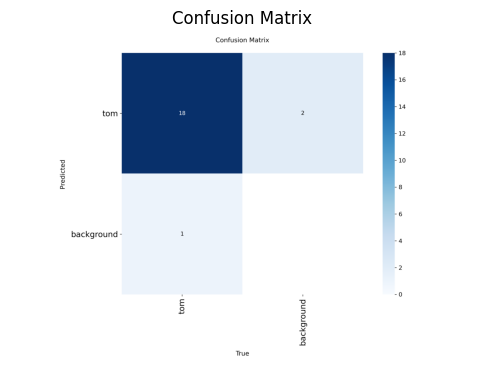

In [43]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(r"C:/transformer_project/runs/detect/runs/detect/tom_jerry_final_run/confusion_matrix.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.title("Confusion Matrix")
plt.show()

<h3>Precison and Recall</h3>

In [2]:
import pandas as pd

df = pd.read_csv(r"C:/transformer_project/runs/detect/runs/detect/tom_jerry_final_run/results.csv")

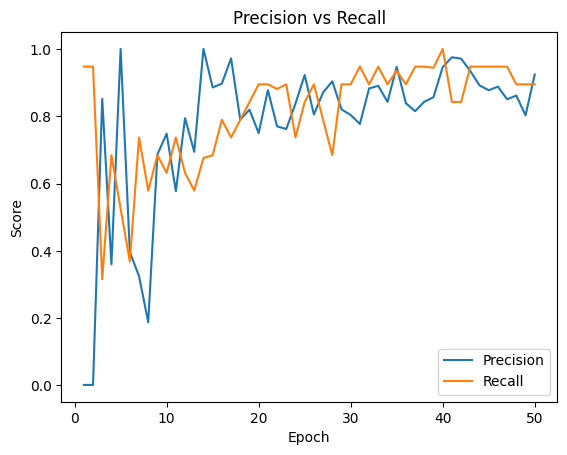

In [3]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")

plt.title("Precision vs Recall")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.show()

<h3>Loss</h3>

In [46]:
import os
import pandas as pd

base = r"C:/transformer_project"

csv_path = None

for root, dirs, files in os.walk(base):
    if "results.csv" in files:
        csv_path = os.path.join(root, "results.csv")
        print("FOUND:", csv_path)
        break

df = pd.read_csv(csv_path)

FOUND: C:/transformer_project\runs\detect\runs\detect\tom_jerry_final_run\results.csv


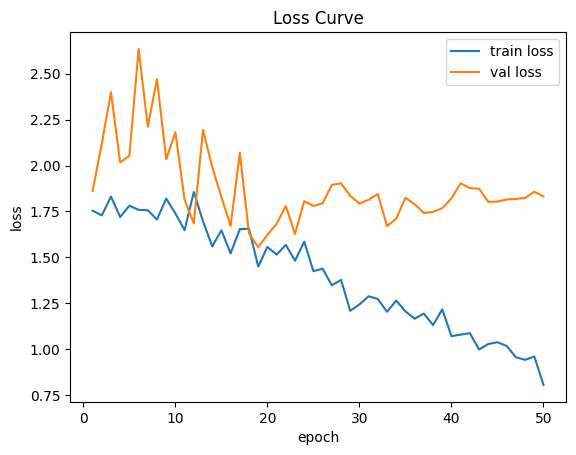

In [48]:
plt.figure()
plt.plot(df["epoch"], df["train/box_loss"], label="train loss")
plt.plot(df["epoch"], df["val/box_loss"], label="val loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Loss Curve")
plt.legend()
plt.show()

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:/transformer_project/runs/detect/runs/detect/tom_jerry_final_run/results.csv")

<h3>map50</h3>

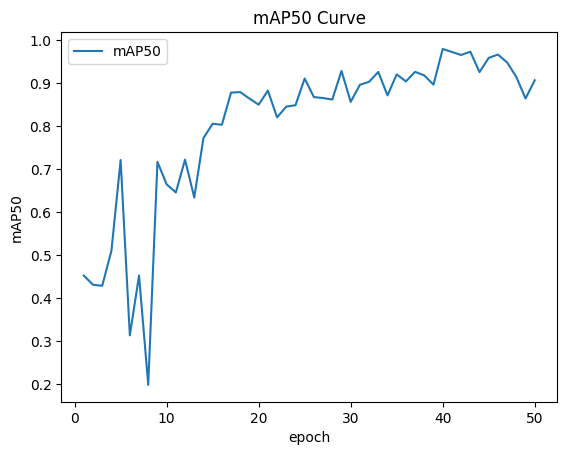

In [49]:
plt.figure()
plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
plt.xlabel("epoch")
plt.ylabel("mAP50")
plt.title("mAP50 Curve")
plt.legend()
plt.show()

<h3>Some of Prediction</h3>

In [53]:
import os

folder = r"runs/detect"

for root, dirs, files in os.walk(folder):
    for f in files:
        if f.endswith((".jpg", ".png")):
            print(os.path.join(root, f))

runs/detect\predict-2\img_11.jpg
runs/detect\predict-2\img_110.jpg
runs/detect\predict-2\img_113.jpg
runs/detect\predict-2\img_115.jpg
runs/detect\predict-2\img_118.jpg
runs/detect\predict-2\img_12.jpg
runs/detect\predict-2\img_131.jpg
runs/detect\predict-2\img_132.jpg
runs/detect\predict-2\img_136.jpg
runs/detect\predict-2\img_137.jpg
runs/detect\predict-2\img_138.jpg
runs/detect\predict-2\img_147.jpg
runs/detect\predict-2\img_155.jpg
runs/detect\predict-2\img_156.jpg
runs/detect\predict-2\img_176.jpg
runs/detect\predict-2\img_183.jpg
runs/detect\predict-2\img_188.jpg
runs/detect\predict-2\img_193.jpg
runs/detect\predict-2\img_194.jpg
runs/detect\predict-2\img_197.jpg
runs/detect\predict-2\img_20.jpg
runs/detect\predict-2\img_26.jpg
runs/detect\predict-2\img_30.jpg
runs/detect\predict-2\img_34.jpg
runs/detect\predict-2\img_37.jpg
runs/detect\predict-2\img_4.jpg
runs/detect\predict-2\img_41.jpg
runs/detect\predict-2\img_45.jpg
runs/detect\predict-2\img_48.jpg
runs/detect\predict-2\img_

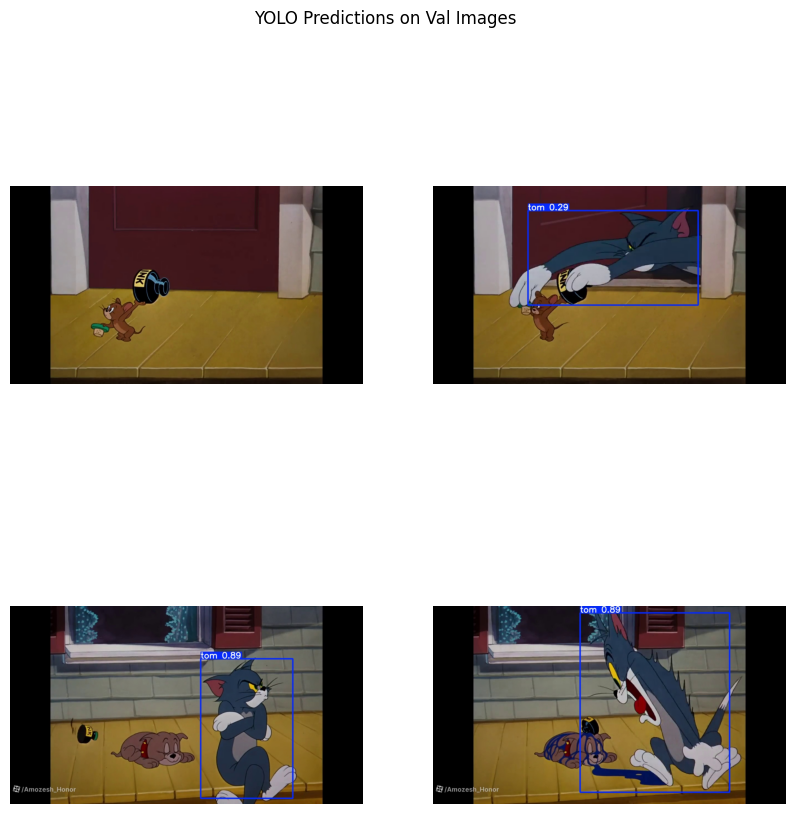

In [55]:
import matplotlib.pyplot as plt
import cv2

img_list = [
    r"runs/detect/predict-2/img_11.jpg",
    r"runs/detect/predict-2/img_12.jpg",
    r"runs/detect/predict-2/img_30.jpg",
    r"runs/detect/predict-2/img_41.jpg"
]

plt.figure(figsize=(10,10))

for i, path in enumerate(img_list):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.suptitle("YOLO Predictions on Val Images")
plt.show()

<h3>Final Metrics Summary</h3>

In [ ]:
import pandas as pd


csv_path = r"C:/transformer_project/runs/detect/runs/detect/tom_jerry_final_run/results.csv"

df = pd.read_csv(csv_path)


final = df.iloc[-1]


metrics_summary = {
    "Final Epoch": final["epoch"],
    "Final Train Loss": final["train/box_loss"],
    "Final Val Loss": final["val/box_loss"],
    "Precision": final["metrics/precision(B)"],
    "Recall": final["metrics/recall(B)"],
    "mAP50": final["metrics/mAP50(B)"],
    "mAP50-95": final["metrics/mAP50-95(B)"]
}


for k, v in metrics_summary.items():
    print(f"{k}: {v:.4f}")

Final Epoch: 50.0000
Final Train Loss: 0.8053
Final Val Loss: 1.8320
Precision: 0.9237
Recall: 0.8947
mAP50: 0.9066
mAP50-95: 0.4790
